<a href="https://colab.research.google.com/github/ArchanaGajendra/Data-science-projects/blob/main/Linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#### Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DATASETS/advertising.csv')
print('The Total instances in the Dataset:', data.shape[0])

The Total instances in the Dataset: 200


In [ ]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
print('No. of Records:',data.shape[0])
print('No. of Features:',data.shape[1])
print('Features:', data.columns)

No. of Records: 200
No. of Features: 4
Features: Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
#Checking for missing values
data.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


<Axes: xlabel='Newspaper', ylabel='Sales'>

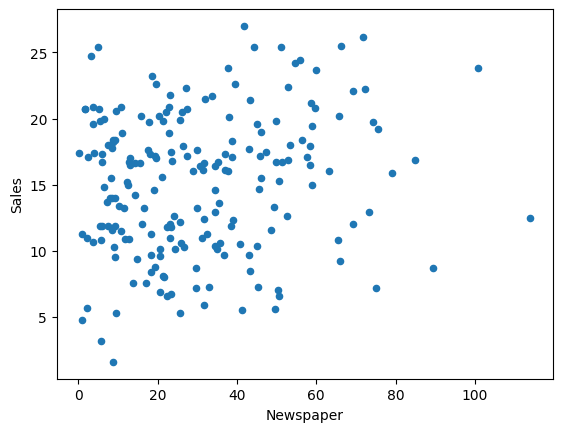

In [ ]:
# Visualise the relationship between the feature (TV Marketing) and the response (Sales) using scatterplots
data.plot(x='Newspaper',y='Sales',kind='scatter')


In [ ]:
#### Splitting Train and Test Dataset
X = data['Newspaper']
y = data['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state = 0)


In [ ]:
# Size of the Train and Test dataset
print('Train Set:',X_train.shape[0])
print('Test Set',X_test.shape[0])


Train Set: 150
Test Set 50


In [ ]:
#### Model Building # Model Fitting
lr = LinearRegression()
lr.fit(X_train.values.reshape(-1,1), y_train)

LinearRegression()

In [ ]:
# Print the intercept and coefficients
print('Intercept = ',lr.intercept_)
print('Coefficient = ',lr.coef_)


Intercept =  13.889764465968996
Coefficient =  [0.05490813]


In [ ]:
#### Prediction of Test Dataset
y_pred = lr.predict(X_test.values.reshape(-1,1)) # Print the predicted values
print("Prediction for test set:",y_pred)


Prediction for test set: [14.89458316 14.90007397 15.16363297 16.70106047 15.82253047 15.52053578
 18.00787385 14.36746515 17.50820991 14.66945984 16.89323891 15.31188491
 14.3455019  14.41139166 15.11421566 14.52669872 13.9062369  14.36746515
 16.39906579 14.60906091 17.83216785 14.38393759 15.61937041 15.7895856
 15.06479834 14.57062522 14.85614747 14.96596372 14.74633122 16.26728629
 20.14929073 17.18425198 15.9213651  15.16363297 16.61320747 15.17461459
 16.25630466 17.09639898 15.84449372 15.52053578 17.49173748 14.01056234
 14.58160684 14.47728141 17.05247248 14.35099272 13.94467259 18.79855086
 18.23848798 15.77860397]


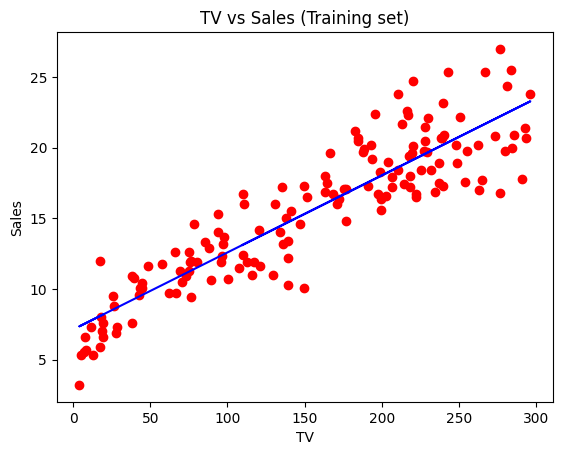

In [ ]:
plt.scatter(X_train, y_train, color = "red")
plt.plot(X_train, lr.predict(np.array(X_train).reshape(-1,1)), color = "blue")
plt.title("Newspaper vs Sales (Training set)")
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.show()

In [ ]:
#### Evaluation of the Model
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
print('Mean Squared Error = ',mse)
print('R Squared = ', r_squared)


Mean Squared Error =  34.98769075674634
R Squared =  -0.13309211214622563


Text(0, 0.5, 'Sales')

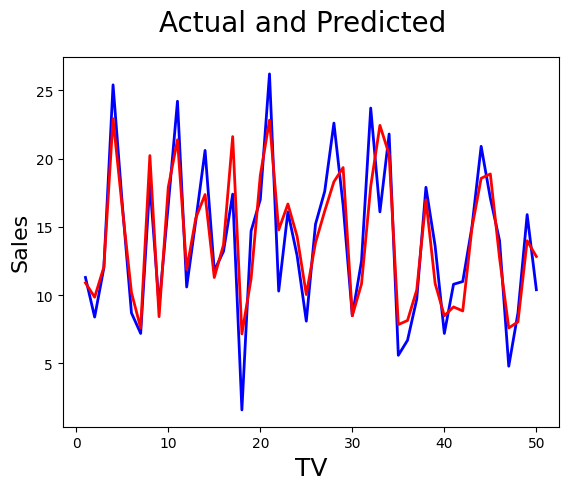

In [ ]:
#### Visualization of Error # Actual vs Predicted
c = [i for i in range(1,len(y_test)+1,1)]
fig = plt.figure()
plt.plot(c,y_test, color="blue", linewidth=2, linestyle="-")
plt.plot(c,y_pred, color="red", linewidth=2, linestyle="-")
fig.suptitle('Actual and Predicted', fontsize=20)
plt.xlabel('TV', fontsize=18)
plt.ylabel('Sales', fontsize=16)


In [ ]:
#### Prediction for a New Unseen Record
new_rec = np.array([24])
print('Predicted Sales is:')
lr.predict(new_rec.reshape(-1,1))


Predicted Sales is:


array([8.43757124])